In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import math

# Create random input and output data
x = np.linspace(-math.pi, math.pi, 2000)
y = np.sin(x)

In [ ]:
a = np.random.randn()
b = np.random.randn()
c = np.random.randn()
d = np.random.randn()
print(f'a={a},b={b},c={c},d={d}')
learning_rate = 1e-6
steps = 2000
loss = np.zeros(steps)
for t in range(steps):
    y_pred = a + b*x+c*(x**2) + d*(x**3)
    iloss = np.square(y_pred-y).sum()
    loss[t] = iloss
    if t % 500 == 0:
        print(f"loss={iloss}, y_pred={y_pred}")

    # Backprop to compute gradients of a, b, c, d with respect to loss
    grad_y_pred = 2.0 * (y_pred-y)
    grad_a = grad_y_pred.sum()
    grad_b = (grad_y_pred * x).sum()
    grad_c = (grad_y_pred * x**2).sum()
    grad_d = (grad_y_pred * x**3).sum()

    a -= learning_rate * grad_a
    b -= learning_rate * grad_b
    c -= learning_rate * grad_c
    d -= learning_rate * grad_d

In [ ]:
from matplotlib import pyplot as plt
plt.plot(np.arange(steps), loss)

Switching to Tensors

In [ ]:
import torch
import math
from matplotlib import pyplot as plt

In [ ]:
dtype = torch.float
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")
torch.set_default_device(device)
# device = torch.device("cuda:0") # Uncomment this to run on GPU

In [ ]:
x = torch.linspace(-math.pi, math.pi, 2000, dtype=dtype)
y = torch.sin(x)

In [ ]:
class LegendrePoly3(torch.autograd.Function):
    @staticmethod
    def forward(ctx, input):
        ctx.save_for_backward(input)
        return 0.5 * (5 * input ** 3 - 3 * input)

    @staticmethod
    def backward(ctx, grad_output):
        input, = ctx.saved_tensors
        return grad_output * 1.5 * (5 * input ** 2 - 1)

In [ ]:
# a = torch.randn((), dtype=dtype, requires_grad=True)
# b = torch.randn((), dtype=dtype, requires_grad=True)
# c = torch.randn((), dtype=dtype, requires_grad=True)
# d = torch.randn((), dtype=dtype, requires_grad=True)

a = torch.full((), 0.0, device=device, dtype=dtype, requires_grad=True)
b = torch.full((), -1.0, device=device, dtype=dtype, requires_grad=True)
c = torch.full((), 0.0, device=device, dtype=dtype, requires_grad=True)
d = torch.full((), 0.3, device=device, dtype=dtype, requires_grad=True)
print(f'a={a.item()},b={b.item()},c={c.item()},d={d.item()}')

learning_rate = 1e-6
steps = 2000
loss_list = list()
for t in range(steps):
    P3 = LegendrePoly3.apply
    
    y_pred = a + b * P3(c+d * x)
    loss = (y_pred - y).pow(2).sum()
    loss_list.append(loss.item())
    if t % 250 == 0:
        print(f"t={t}, loss={loss.item()}")

    loss.backward()

    with torch.no_grad():
        # grad_y_pred = 2.0 * (y_pred - y)
        # grad_a = grad_y_pred.sum()
        # grad_b = (grad_y_pred * x).sum()
        # grad_c = (grad_y_pred * (x ** 2)).sum()
        # grad_d = (grad_y_pred * (x ** 3)).sum()

        a -= learning_rate*a.grad
        b -= learning_rate*b.grad
        c -= learning_rate*c.grad
        d -= learning_rate*d.grad

        # reset gradient after updating weights
        a.grad = None
        b.grad = None
        c.grad = None
        d.grad = None

print(f'Result: y = {a.item()} + {b.item()} x + {c.item()} x^2 + {d.item()} x^3')

In [ ]:
plt.plot(np.arange(steps), loss_list)

In [ ]:
x = torch.linspace(-math.pi, math.pi, 2000, dtype=dtype)
p = torch.tensor([1,2,3])
xx = x.unsqueeze(-1).pow(p)

model = torch.nn.Sequential(
    torch.nn.Linear(3,1),
    torch.nn.Flatten(0,1)
)

loss_fn = torch.nn.MSELoss(reduction="sum")

In [ ]:
learning_rate = 1e-6
optimizer = torch.optim.RMSprop(model.parameters(), lr=learning_rate)
steps = 2000
loss_list = list()
for t in range(steps):
    y_pred = model(xx)
    loss = loss_fn(y_pred, y)
    if t % 250 == 100:
        print(t, loss.item())

    optimizer.zero_grad()
    loss.backward()
    loss_list.append(loss.item())
    optimizer.step()

linear_layer = model[0]

In [ ]:
print(f'Result: y = {linear_layer.bias.item()} + {linear_layer.weight[:, 0].item()} x + {linear_layer.weight[:, 1].item()} x^2 + {linear_layer.weight[:, 2].item()} x^3')
plt.plot(np.arange(steps), loss_list)

In [3]:
import torch
import math
from matplotlib import pyplot as plt

dtype = torch.float
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")
torch.set_default_device(device)

Using mps device


In [6]:

# device = torch.device("cuda:0") # Uncomment this to run on GPU
class Poly3(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.a = torch.nn.Parameter(torch.randn(()))
        self.b = torch.nn.Parameter(torch.randn(()))
        self.c = torch.nn.Parameter(torch.randn(()))
        self.d = torch.nn.Parameter(torch.randn(()))

    def forward(self, x):
        return self.a + self.b*x + self.c*(x**2) + self.d* (x**3)

    def string(self):
        """
        Just like any class in Python, you can also define custom method on PyTorch modules
        """
        return f'y = {self.a.item()} + {self.b.item()} x + {self.c.item()} x^2 + {self.d.item()} x^3'

In [7]:
x = torch.linspace(-math.pi, math.pi, 2000, dtype=dtype)
y = torch.sin(x)
model = Poly3()

In [10]:
loss_fn = torch.nn.MSELoss(reduction="sum")
optimizer = torch.optim.SGD(model.parameters(), lr=1e-6)
steps = 2000
loss_list = list()
for t in range(steps):
    y_pred = model(x)
    loss = loss_fn(y_pred, y)
    loss_list.append(loss.item())
    model.zero_grad()
    if t % 250 == 0:
        print(t, loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

0 8.817363739013672
250 8.817237854003906
500 8.817193984985352
750 8.817176818847656
1000 8.817171096801758
1250 8.817169189453125
1500 8.817168235778809
1750 8.817168235778809


Result: [-5.3277485676517244e-06, 0.8567265868186951, 9.199996497954999e-07, -0.09332836419343948]


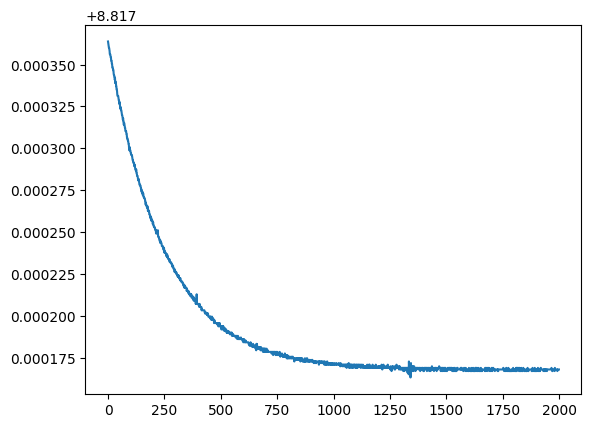

In [15]:
print(f'Result: {[w.item() for w in model.parameters()]}')
plt.plot(list(range(steps)), loss_list)